# Optimal path between sites

This notebook shows how to use [GEMDAT](https://gemdat.readthedocs.org) to compute the optimal path between two sites.

It first computes the free energy on a discretized grid from the trajectory, then it finds the nearest sites of the structure to each point of the grid to map the space. Now the user can specify the start and end points of the path, and the metrics to compute the best path.

As input you will need:

1. discretized grid resolution
    - float value
2. start point of the path
    - a tuple representing the (x,y,z) coordinates of the start point 
3. end point of the path
    - a tuple representing the (x,y,z) coordinates of the end point
4. pathfinding algorithm, that can be one of the following:
    - Dijkstra algorithm through [`networkx.short_path`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path.html#networkx.algorithms.shortest_paths.generic.shortest_path)
    - Bellman-Ford algorithm through [`networkx.short_path`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path.html#networkx.algorithms.shortest_paths.generic.shortest_path)
    - Minimal maximum energy
    - Dijkstra but with exponentially scaled energy

The resulting path can be analyzed and plotted in 3d, together with the energy profile along the path.

## Loading data

Load simulation data and reference jump sites.

In [1]:
from gemdat import Trajectory
from gemdat.io import load_known_material
from gemdat.utils import VASPRUN

# Use your own data:
# VASPRUN = 'path/to/your/vasprun.xml'

trajectory = Trajectory.from_vasprun(VASPRUN)
diff_trajectory = trajectory.filter('Li')

sites = load_known_material('argyrodite', supercell=(2, 1, 1))

## Generate free energy graph

The next step is to generate the free energy graph. This uses the density volume, where every grid point (voxel) becomes a node in the graph.

Resolution is the minimum size of the voxels in Ångstrom.

Notice that there are points where it is numerically impossible to find mobile atoms. In such points the free energy is infinite and it can cause numerical instabilities.

In [2]:
volume = trajectory.to_volume(resolution=0.45)

free_energy = volume.get_free_energy(temperature=trajectory.metadata['temperature'])

## Define path

Select a start and an end point for the path.

For this example, we select two peaks of the density volume. The volume is converted into a pymatgen structure to make it easier to work with. Any integer voxel coordinate (`start_point`, `stop_point`) can be used to define the path.

In [3]:
peaks = volume.to_structure()

start_site = peaks[0]
stop_site = peaks[100]

print(start_site, '->', stop_site)

start_point = volume.site_to_voxel(start_site)
stop_point = volume.site_to_voxel(stop_site)

print(start_point, '->', stop_point)

[10.1513076   1.57875625  1.49884936] X0+ -> [2.496801   7.49305245 7.33775091] X0+
[22  3  3] -> [ 5 16 16]


### 0. Unweighted path

First we define a path as the direct (unweighted) path between the start and the stop point. This result is unrealistic and has low probability. It gives a baseline energy and shows the contrast with the energy optimized path. 

In [4]:
path0 = free_energy.optimal_path(
    start=start_point,
    stop=stop_point,
    method='simple',
)

path0

Path: (np.int64(22), np.int64(3), np.int64(3)) -> (np.int64(5), np.int64(16), np.int64(16))
Steps: 28
Total energy: 15.560 eV
Dimensions: (44, 22, 22)

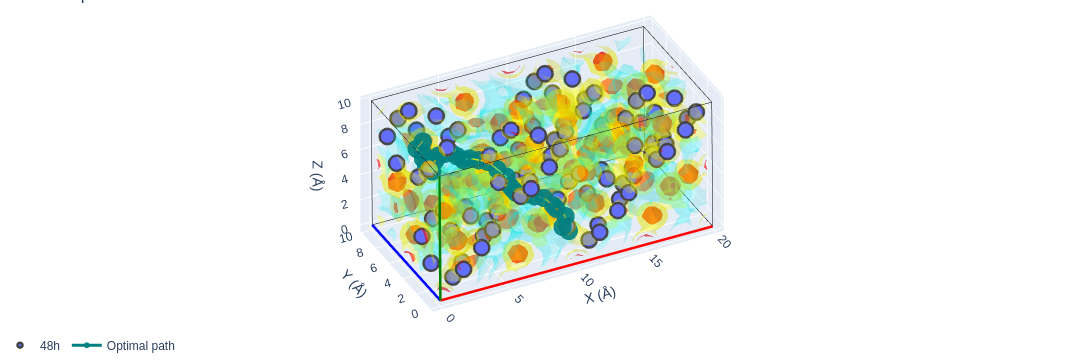

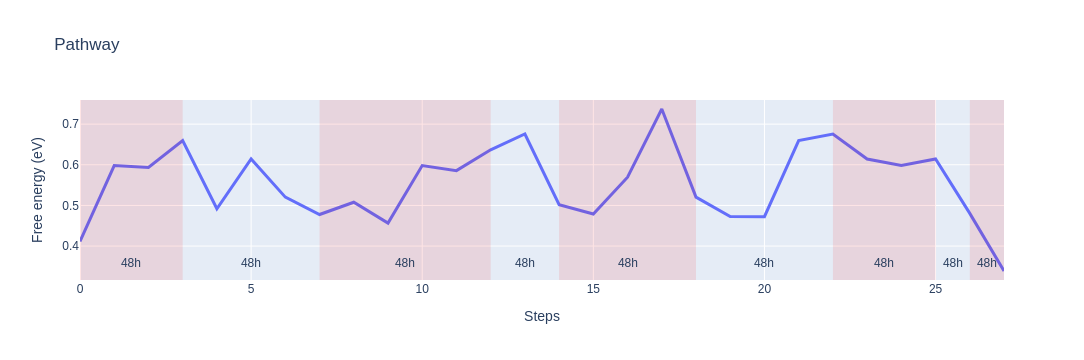

In [5]:
fig1 = volume.plot_3d(structure=sites, paths=path0)
fig1.show()

fig2 = path0.plot_energy_along_path(structure=sites)
fig2.show()

### 1. Dijkstra

In [6]:
path1 = free_energy.optimal_path(
    start=start_point,
    stop=stop_point,
    method='dijkstra',
)

path1

Path: (np.int64(22), np.int64(3), np.int64(3)) -> (np.int64(5), np.int64(16), np.int64(16))
Steps: 28
Total energy: 14.507 eV
Dimensions: (44, 22, 22)

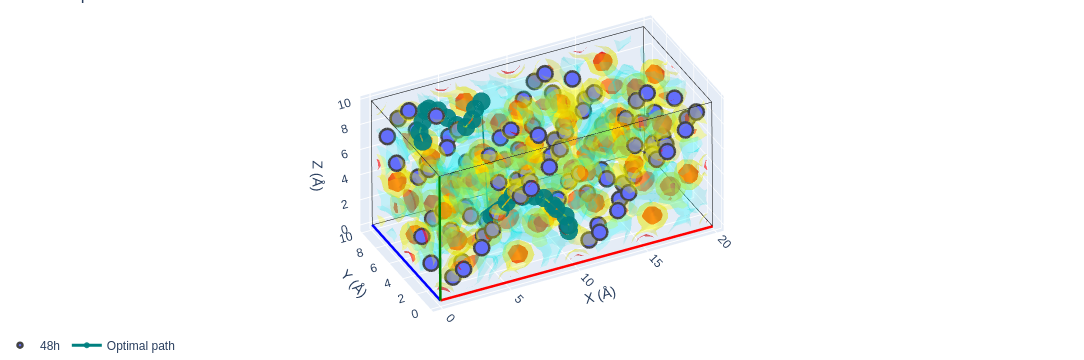

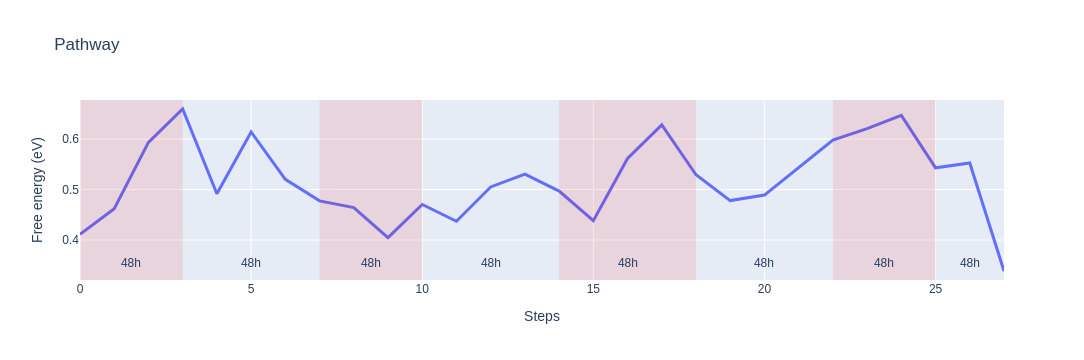

In [7]:
fig1 = volume.plot_3d(structure=sites, paths=path1)
fig1.show()

fig2 = path1.plot_energy_along_path(structure=sites)
fig2.show()

### 2. Bellman-Ford

In [8]:
path2 = free_energy.optimal_path(
    start=start_point,
    stop=stop_point,
    method='bellman-ford',
)

path2

Path: (np.int64(22), np.int64(3), np.int64(3)) -> (np.int64(5), np.int64(16), np.int64(16))
Steps: 28
Total energy: 14.507 eV
Dimensions: (44, 22, 22)

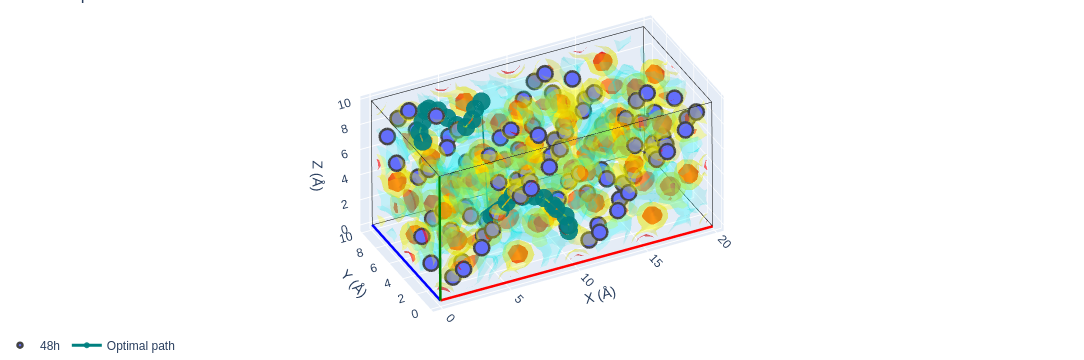

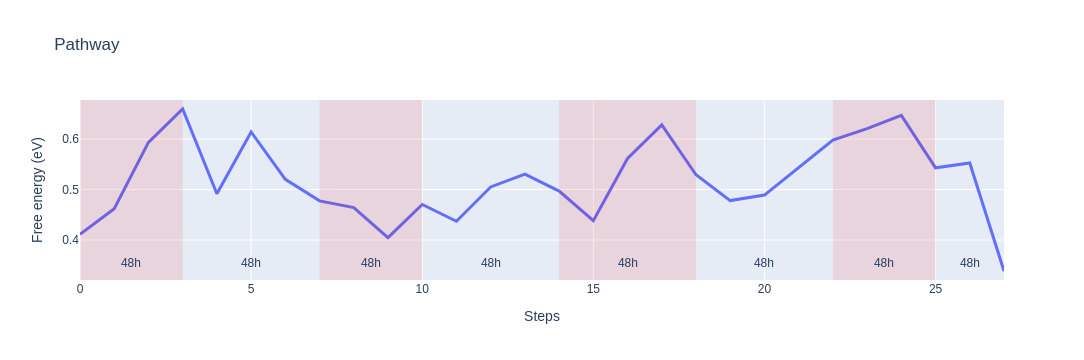

In [9]:
fig1 = volume.plot_3d(structure=sites, paths=path2)
fig1.show()

fig2 = path2.plot_energy_along_path(structure=sites)
fig2.show()

### 3. Minimum maximum energy

This method tries to find the path with the lowest overall maximum energy. This can result in an path that is longer, but overall more efficient.

In [10]:
path3 = free_energy.optimal_path(
    start=start_point,
    stop=stop_point,
    method='minmax-energy',
)

path3

Path: (np.int64(22), np.int64(3), np.int64(3)) -> (np.int64(5), np.int64(16), np.int64(16))
Steps: 28
Total energy: 14.507 eV
Dimensions: (44, 22, 22)

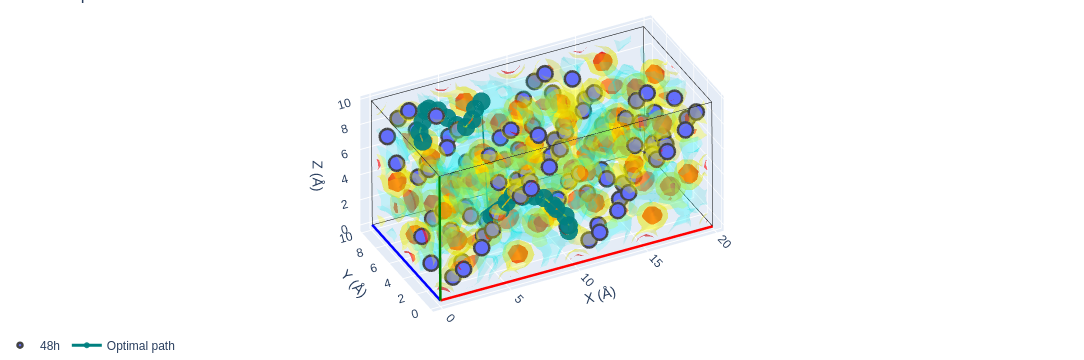

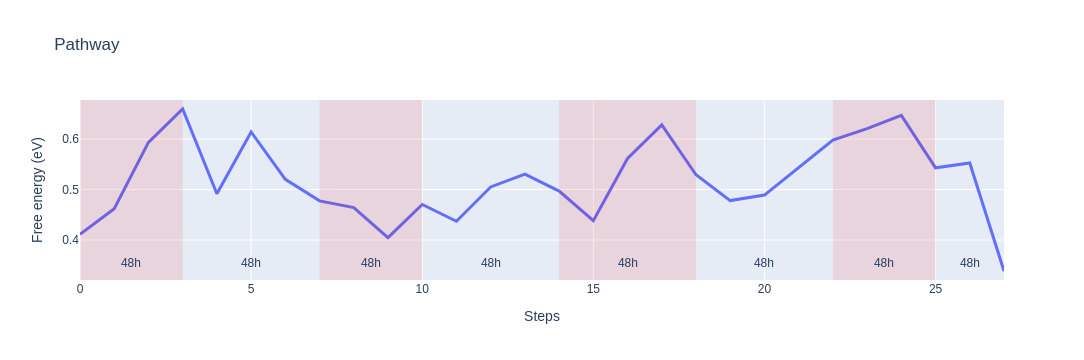

In [11]:
fig1 = volume.plot_3d(structure=sites, paths=path3)
fig1.show()

fig2 = path3.plot_energy_along_path(structure=sites)
fig2.show()

### 4. exponential Dijkstra

In [12]:
path4 = free_energy.optimal_path(
    start=start_point,
    stop=stop_point,
    method='dijkstra-exp',
)

path4

Path: (np.int64(22), np.int64(3), np.int64(3)) -> (np.int64(5), np.int64(16), np.int64(16))
Steps: 28
Total energy: 14.507 eV
Dimensions: (44, 22, 22)

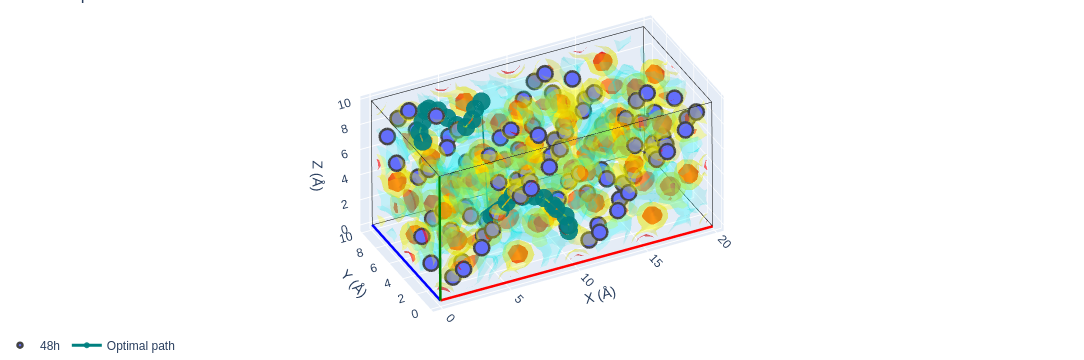

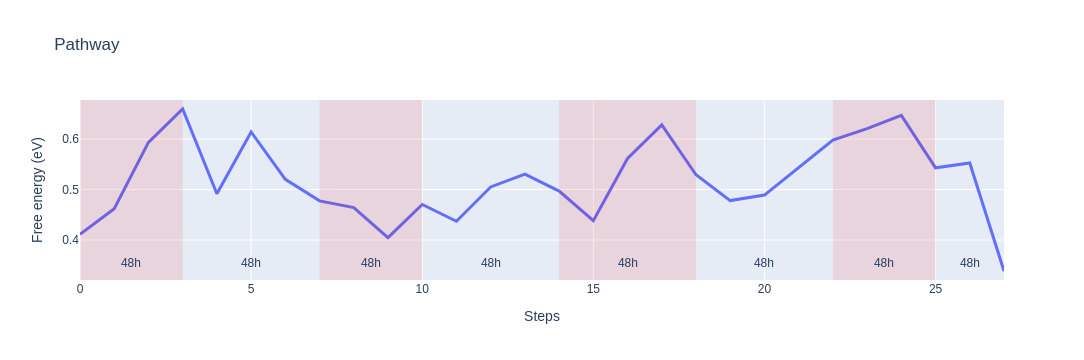

In [13]:
fig1 = volume.plot_3d(structure=sites, paths=path4)
fig1.show()

fig2 = path4.plot_energy_along_path(structure=sites)
fig2.show()

## Comparison

As a final comparison, plot the energy of the paths identified with the different algorithms.

Notice from the figure above that `dijkstra`, `dijksta-exp` and `bellman-ford` identify the same path, while `minmax-energy` is able to find a path with a smaller highest-barrier, but sometimes a bit longer.

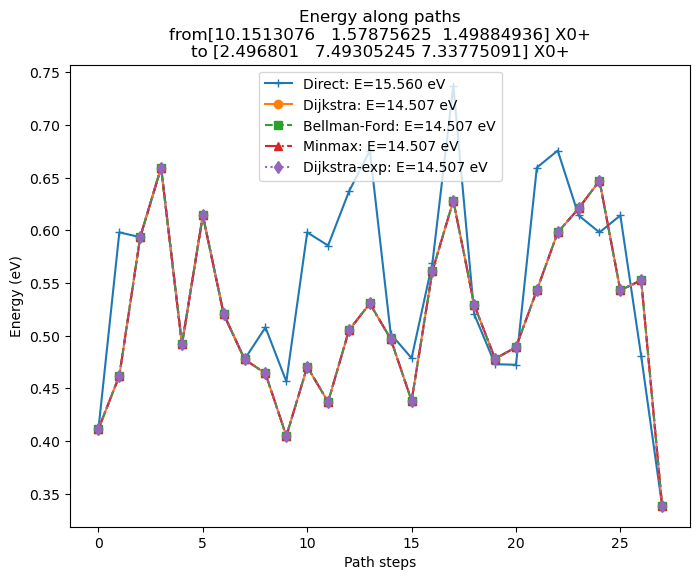

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

for path, label, ls, m in (
    (path0, 'Direct', 'solid', '+'),
    (path1, 'Dijkstra', '-', 'o'),
    (path2, 'Bellman-Ford', '--', 's'),
    (path3, 'Minmax', '-.', '^'),
    (path4, 'Dijkstra-exp', ':', 'd'),
):
    axs.plot(
        path.energy,
        label=f'{label}: E={path.total_energy:.3f} eV',
        linestyle=ls,
        marker=m,
    )

axs.set_xlabel('Path steps')
axs.set_ylabel('Energy (eV)')
axs.legend()
axs.set_title(f'Energy along paths\nfrom{start_site}\nto {stop_site}');